# 📌 Customer Lifetime Value (LTV) Prediction

**Objective:** Predict the lifetime value of customers based on purchase behavior to support targeted marketing strategies.

**Tools Used:** Python, Pandas, Scikit-learn, XGBoost, Matplotlib

**Dataset:** Online Retail Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1️⃣ Data Loading

In [2]:
df = pd.read_csv("online_retail.csv", encoding='ISO-8859-1')
df.shape
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## 2️⃣ Data Cleaning

In [3]:
# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')

# Remove missing customers
df = df.dropna(subset=['CustomerID'])

# Remove negative quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Cleaned shape:", df.shape)

Cleaned shape: (397884, 9)


## 3️⃣ Feature Engineering (RFM + AOV)

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary'
})

# Average Order Value
customer_df['AOV'] = customer_df['Monetary'] / customer_df['Frequency']

customer_df.head()

,Recency,Frequency,Monetary,AOV
CustomerID,,,,
12346.0,326,1,77183.60,77183.600000
12347.0,2,7,4310.00,615.714286
12348.0,75,4,1797.24,449.310000
12349.0,19,1,1757.55,1757.550000
12350.0,310,1,334.40,334.400000


## 4️⃣ Target Variable (LTV)
### Log Transformation

LTV distribution is highly right-skewed due to a small number of high-value customers.
To stabilize variance and improve model learning, log transformation was applied to the target variable.

In [5]:
customer_df['LTV'] = customer_df['Monetary']
customer_df['LTV_log'] = np.log1p(customer_df['LTV'])

customer_df[['LTV', 'LTV_log']].describe()

,LTV,LTV_log
count,4338.000000,4338.000000
mean,2054.266460,6.593627
std,8989.230441,1.257578
min,3.750000,1.558145
25%,307.415000,5.731446
50%,674.485000,6.515431
75%,1661.740000,7.416222
max,280206.020000,12.543284


## 5️⃣ Exploratory Data Analysis

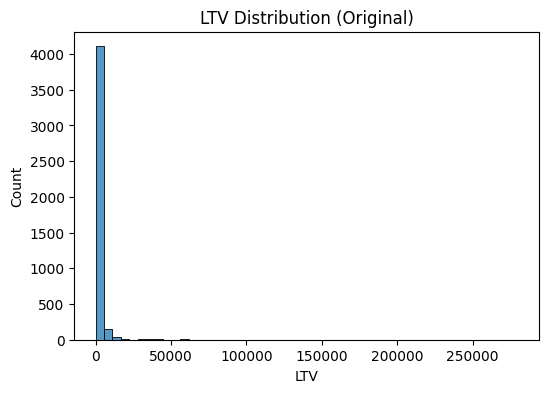

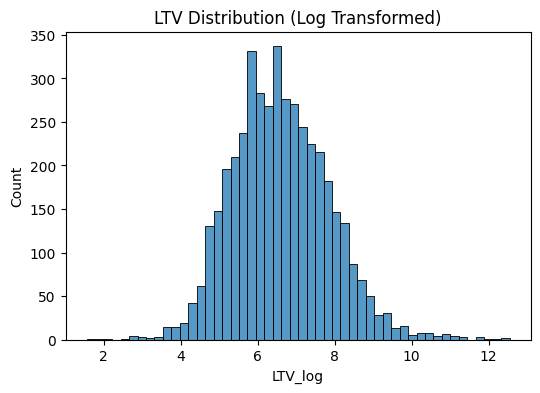

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(customer_df['LTV'], bins=50)
plt.title("LTV Distribution (Original)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(customer_df['LTV_log'], bins=50)
plt.title("LTV Distribution (Log Transformed)")
plt.show()

## 6️⃣ Train Test Split

In [7]:
X = customer_df[['Recency', 'Frequency', 'AOV']]
y = customer_df['LTV_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

## 7️⃣ Model Training (XGBoost)

In [8]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
joblib.dump(xgb_model, "ltv_xgboost_model.pkl")

['ltv_xgboost_model.pkl']

### 🔁 Cross-Validation

To ensure model robustness and reduce overfitting risk, 5-fold cross-validation was performed.

In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error'
)

cv_mae = -cv_scores.mean()
cv_std = cv_scores.std()

print(f"CV MAE: {cv_mae:.4f}")
print(f"CV Std Dev: {cv_std:.4f}")

CV MAE: 0.0273
CV Std Dev: 0.0033


## 8️⃣ Model Evaluation
### 📊 Model Performance Interpretation

The low MAE and RMSE values indicate strong predictive performance.
The closeness of both metrics suggests the model is not heavily affected by extreme outliers.

In [11]:
y_pred_log = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_log)
rmse = mean_squared_error(y_test, y_pred_log, squared=False)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

MAE: 0.0236
RMSE: 0.0643


In [12]:
customer_df['Predicted_LTV_log'] = xgb_model.predict(X)
customer_df['Predicted_LTV'] = np.expm1(customer_df['Predicted_LTV_log'])

### 🔍 Residual Analysis

Residual analysis was performed to check for systematic prediction errors and model bias.

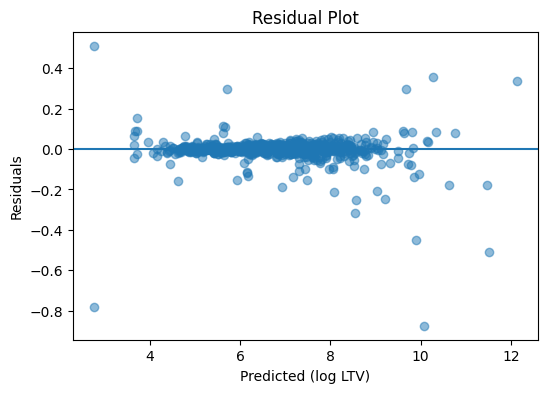

In [13]:
# Residuals
y_pred_test = xgb_model.predict(X_test)
residuals = y_test - y_pred_test

plt.figure(figsize=(6,4))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted (log LTV)")
plt.ylabel("Residuals")
plt.show()

Residuals appear randomly scattered around zero, indicating no strong systematic bias in model predictions.

## 9️⃣ Customer Segmentation

In [14]:
customer_df['Customer_Segment'] = pd.qcut(
    customer_df['Predicted_LTV'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

customer_df['Customer_Segment'].value_counts()

Customer_Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

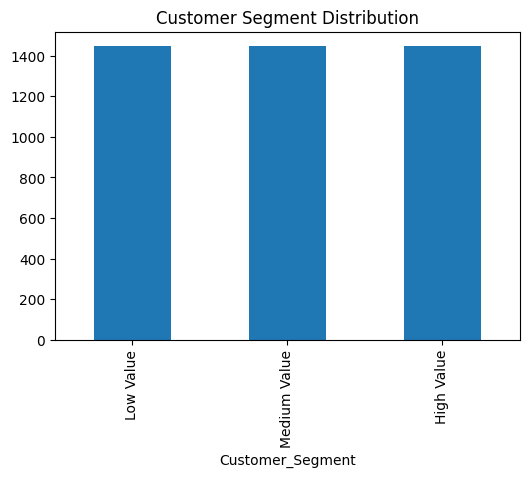

In [15]:
plt.figure(figsize=(6,4))
customer_df['Customer_Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.show()

### 💰 Business Impact

High-value customers represent the primary revenue drivers.
Targeted retention campaigns focused on this segment can significantly improve marketing ROI and customer profitability.

## 🧾 Executive Summary

This project developed an LTV prediction model using RFM-based behavioral features.
The model enables marketing teams to identify high-value customers and optimize retention strategies.

In [16]:
segment_summary = customer_df.groupby('Customer_Segment').agg({
    'Predicted_LTV': ['count', 'mean']
}).round(2)

segment_summary

Predicted_LTV             
                         count         mean
Customer_Segment                           
Low Value                 1446   220.500000
Medium Value              1446   712.369995
High Value                1446  5210.399902

## 🔍 Model Interpretation — Feature Importance

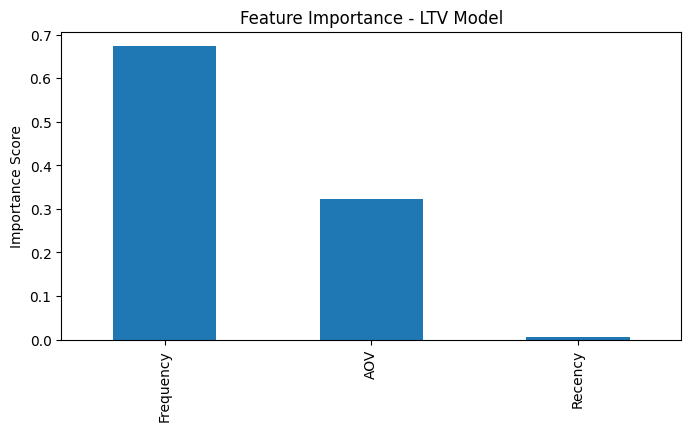

In [17]:
importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,4))
feat_imp.plot(kind='bar')
plt.title("Feature Importance - LTV Model")
plt.ylabel("Importance Score")
plt.show()

## 📤 Final Export

In [18]:
final_output = customer_df.reset_index()[[
    'CustomerID',
    'Predicted_LTV',
    'Customer_Segment'
]]

final_output.to_csv("Customer_LTV_Predictions.csv", index=False)
print("✅ CSV exported successfully")

✅ CSV exported successfully


## 💡 Business Insights

- High-value customers contribute disproportionately to revenue.
- Frequency and AOV are strong predictors of customer lifetime value.
- The model enables targeted marketing campaigns for premium customers.
- Log transformation improved model stability and reduced skewness.

# ✅ Conclusion

An end-to-end Customer Lifetime Value prediction pipeline was successfully built using transactional data.

Key achievements:

- Engineered RFM-based behavioral features
- Applied log transformation to handle skewness
- Trained XGBoost regression model
- Segmented customers into value tiers
- Generated actionable marketing insights

This solution can help businesses prioritize high-value customers and optimize marketing ROI.